### CustIntel Project Report:


In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
%matplotlib inline

sns.set_theme(style="whitegrid")

conn = sqlite3.connect('../data/ecommerce.db')
df_customers = pd.read_sql_query("SELECT * FROM Dim_Customers", conn)
df_fact = pd.read_sql_query("SELECT * FROM Fact_Order_Items WHERE order_purchase_timestamp IS NOT NULL", conn)
df_products = pd.read_sql_query("SELECT * FROM Dim_Products", conn)
conn.close()

df_agg = df_fact.groupby('customer_id').agg(
    total_spend=('price', 'sum'),
    frequency=('order_id', 'nunique')
).reset_index()

## 1. Exploratory Data Analysis (EDA)
### 1.1 Box Plots for Outlier Detection (Whale Spenders)

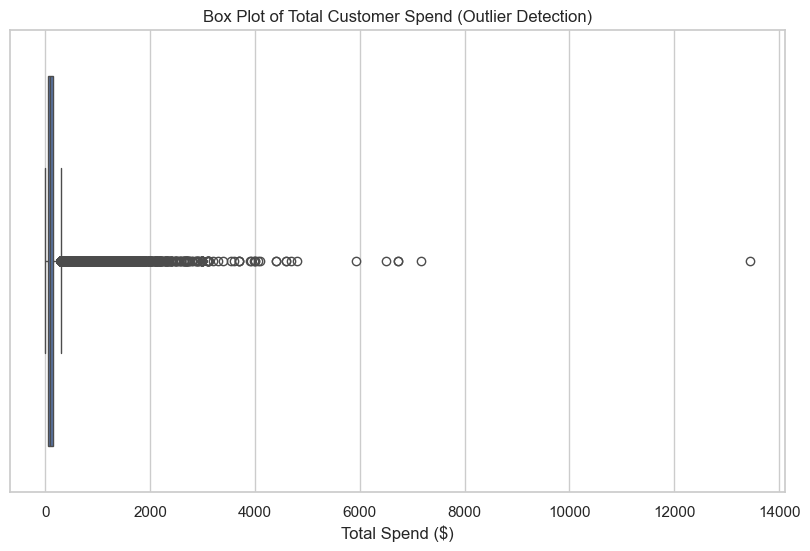

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_agg['total_spend'])
plt.title('Box Plot of Total Customer Spend (Outlier Detection)')
plt.xlabel('Total Spend ($)')
plt.show()

### 1.2 Category Sales Distribution (Stacked Bar Plot)

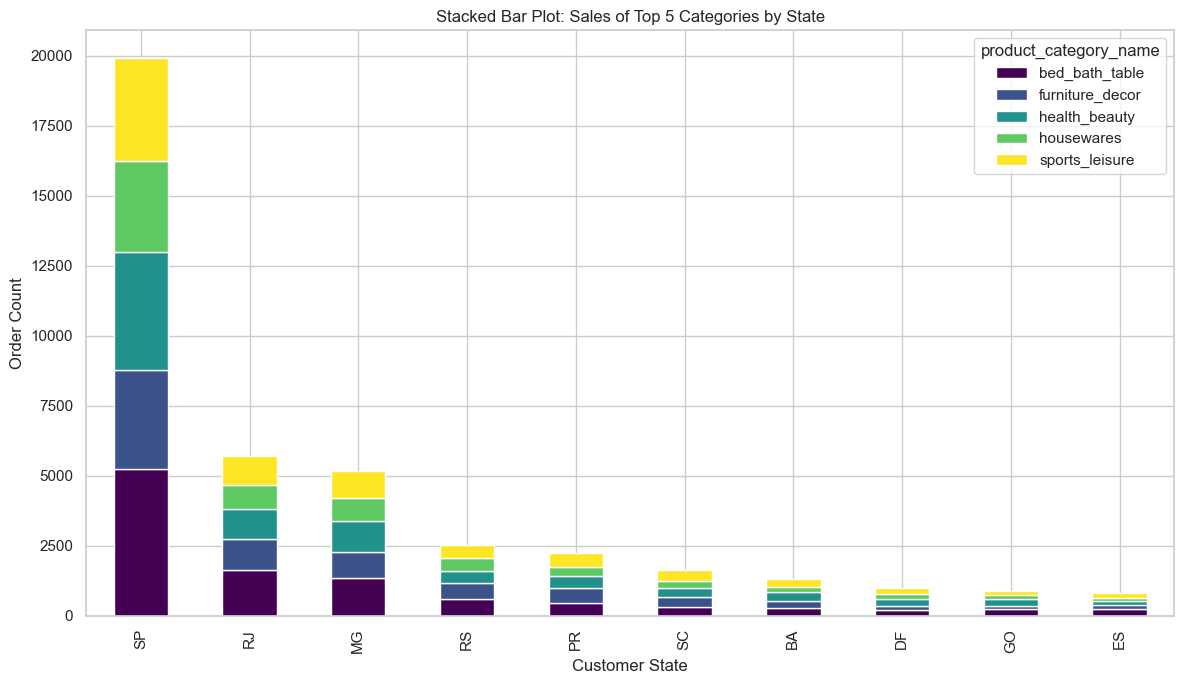

In [27]:
# Stacked Bar Plot: Sales by Customer State for Top 5 Categories
top_5_cats = df_products['product_category_name'].value_counts().head(5).index
merged_df = df_fact.merge(df_products, on='product_id').merge(df_customers, on='customer_id')
stacked_data = merged_df[merged_df['product_category_name'].isin(top_5_cats)]
pivot_df = stacked_data.groupby(['customer_state', 'product_category_name']).size().unstack().fillna(0)
pivot_df = pivot_df.loc[pivot_df.sum(axis=1).sort_values(ascending=False).head(10).index]

fig, ax = plt.subplots(figsize=(12, 7))
pivot_df.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
plt.title('Stacked Bar Plot: Sales of Top 5 Categories by State')
plt.ylabel('Order Count')
plt.xlabel('Customer State')
plt.tight_layout()
plt.show()

### 1.3 Scatter Plot: Frequency vs Total Spend

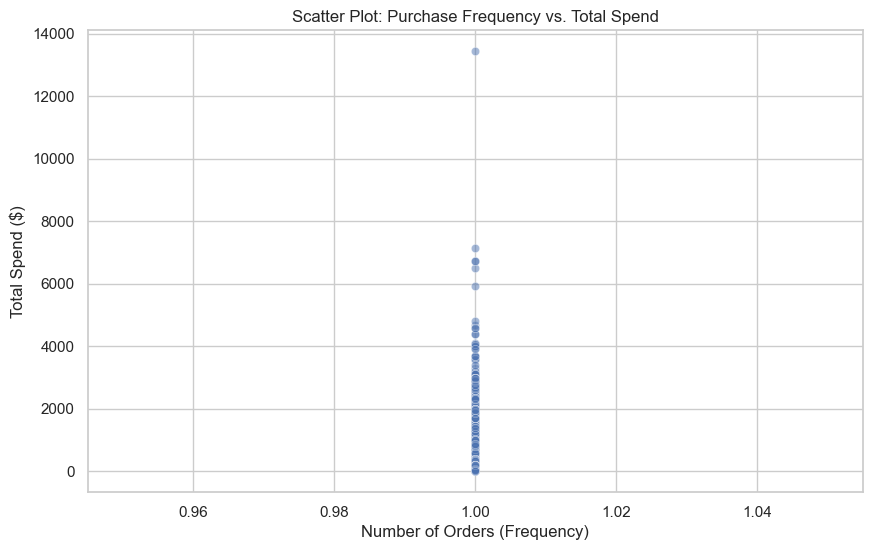

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agg, x='frequency', y='total_spend', alpha=0.5)
plt.title('Scatter Plot: Purchase Frequency vs. Total Spend')
plt.xlabel('Number of Orders (Frequency)')
plt.ylabel('Total Spend ($)')
plt.show()

### 2 OLS Diagnostics for LTV Regressor

In [29]:
try:
    with open('../models/ols_summary.txt', 'r') as f:
        print(f.read())
except FileNotFoundError:
    print("Run `python src/ml_models.py` first to generate OLS diagnostics.")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.149e+33
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:36:39   Log-Likelihood:             2.0664e+06
No. Observations:               76336   AIC:                        -4.133e+06
Df Residuals:                   76332   BIC:                        -4.133e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.938e-13   7.85e-15     37.422

### 3 Loss Curve for Next-Category Predictor

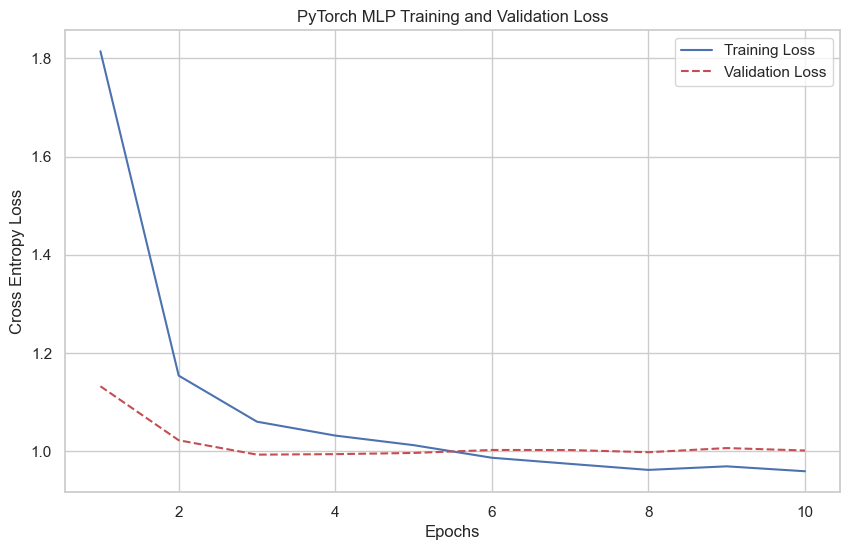

In [30]:
try:
    with open('../models/dl_history.json', 'r') as f:
        history = json.load(f)
        
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss')
    plt.title('PyTorch MLP Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Cross Entropy Loss')
    plt.legend()
    plt.show()
except FileNotFoundError:
    print("Run `python src/dl_model.py` first to generate DL history.")